In [999]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## About this Dataset

In [1000]:
data = pd.read_csv(
    'data/interval_1500.csv',
    usecols=['Unnamed: 0', 'actual power', 'reference power', 'poa irradiance (array tilt)', 'ambient temperature', 'ghi', 'wind speed'],
    index_col='Unnamed: 0',
    parse_dates=True
    )

In [1001]:
DAYS = 30

In [1002]:
start_date = data.index.min()
end_date = start_date + pd.Timedelta(days=DAYS)
data = data[(data.index >= start_date) & (data.index < end_date)]

In [1003]:
power_data = data[['actual power', 'reference power']]

In [1004]:
weather_data = data[['poa irradiance (array tilt)', 'ambient temperature', 'ghi', 'wind speed']]

In [1005]:
DAYS*24*4

2880

1 - Power generation data

In [1006]:
power_data.shape

(2880, 2)

✅ Same number of timestamps respect to the excepted number of timestamps:
2018: 365 days
2019: 365 days
2020: 366 days (leap year)
2021: 365 days

Total = 365 + 365 + 366 + 365 = 1,461 days

In [1007]:
# missing values
power_data.isnull().sum()

actual power       0
reference power    0
dtype: int64

In [1008]:
# nan values
power_data.isna().sum()

actual power       0
reference power    0
dtype: int64

There is no any presence of missing timestamps or nan values in the data of power.

In [1009]:
# missing values
weather_data.isnull().sum()

poa irradiance (array tilt)    0
ambient temperature            0
ghi                            0
wind speed                     0
dtype: int64

In [1010]:
# nan values
weather_data.isna().sum()

poa irradiance (array tilt)    0
ambient temperature            0
ghi                            0
wind speed                     0
dtype: int64

## Exploratory Analysis

In [1011]:
# We extract more features from DATE_TIME
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek

# Convert day of year to days of our study period (1-30)
days = data.index.dayofyear
data['day'] = days.map({days.unique()[i-1]:i for i in range(1, DAYS+1)})

# Step 1: Extract time values from the index as a Series
time_series = pd.Series(data.index.time, index=data.index)

# Step 2: Get sorted unique time values
unique_times = sorted(time_series.unique())

# Step 3: Create a mapping dictionary from time to interval label (1 to 96)
time_to_interval = {t: i+1 for i, t in enumerate(unique_times)}
# Step 4: Map the time values to interval labels
data['interval'] = time_series.map(time_to_interval)


In [1012]:
data['interval'].isnull().sum()

np.int64(0)

In [1013]:
# use data without missing values for the moment
df_na = data[~data.isna()]

## Data Correlation

<Axes: >

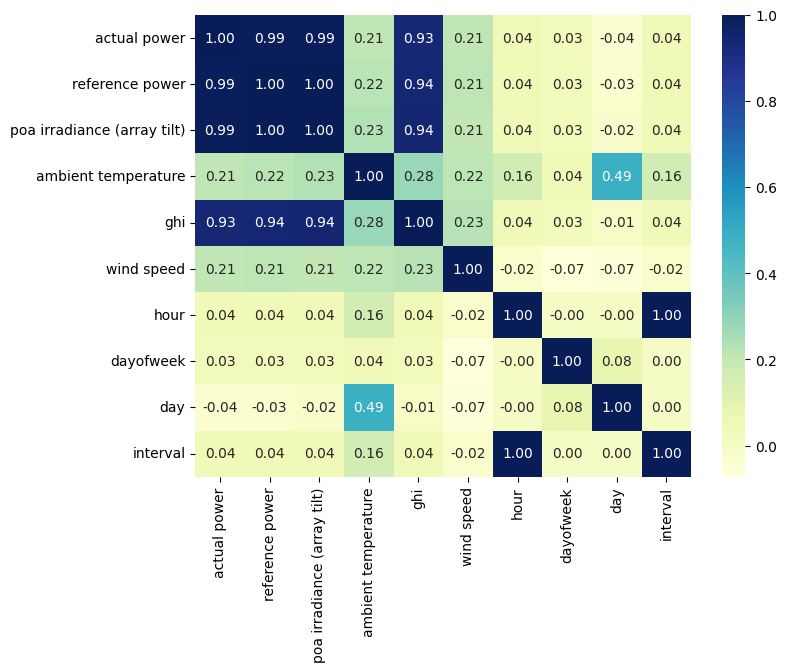

In [1014]:
# Let's see the correlation between our features
plt.figure(figsize=(8, 6))
sns.heatmap(df_na.corr(numeric_only=True), cmap='YlGnBu', fmt='.2f', annot=True)

In [1015]:
def plot_outliers(data, feature):
    """
    Plots outliers for a given feature in the provided data using the percentile method.
    Outliers are detected based on the specified feature and are determined by values
    falling outside the 1% and 99% percentiles for each interval.

    Parameters:
    - data (DataFrame): The input DataFrame containing the data.
    - feature (str): The name of the feature for which outliers will be detected and plotted.
    """

    df = data.copy()
    df = df.merge(df.groupby('interval')
                .quantile(0.01, numeric_only=True)[feature]\
                .rename('OUTLIERS_LOW'),
                 on='interval',
                 how='left')
    df = df.merge(df.groupby('interval')\
                .quantile(0.99, numeric_only=True)[feature]\
                .rename('OUTLIERS_HIGH'),
                 on='interval',
                 how='left')
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=df, y=feature, x='interval', hue='actual power',
                    palette='gray', alpha=0.1, legend=False)
    sns.scatterplot(data=df.query(f"`{feature}` > OUTLIERS_HIGH"), y=feature, x='interval')
    sns.scatterplot(data=df.query(f"`{feature}` < OUTLIERS_LOW"), y=feature, x='interval')

    plt.ylabel(feature)
    plt.xlabel('Hour of Day')
    ax.set_xticks([i for i in range(1, 97, 4)])
    ax.set_xticklabels([i for i in range(24)])
    ax.legend(['data', 'outliers_high', 'outliers_low'])

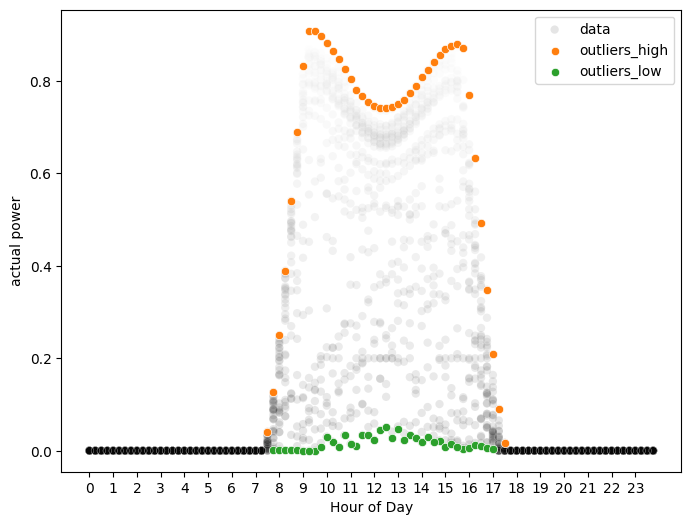

In [1016]:
plot_outliers(df_na, "actual power")

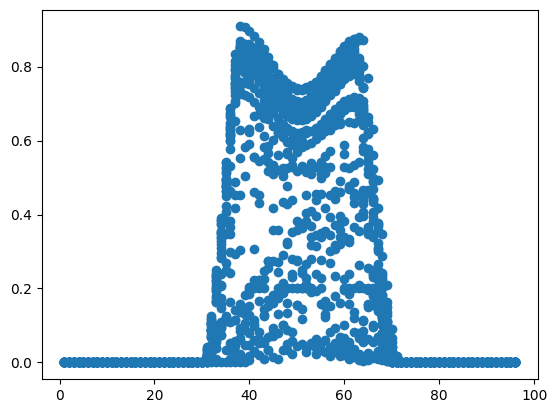

In [1017]:
plt.scatter(df_na['interval'], df_na['actual power'])

In [1018]:
data.isna().sum()

actual power                   0
reference power                0
poa irradiance (array tilt)    0
ambient temperature            0
ghi                            0
wind speed                     0
hour                           0
dayofweek                      0
day                            0
interval                       0
dtype: int64

In [1019]:
data.index = pd.to_datetime(data.index.strftime('%d-%m-%Y %H:%M'), format='%d-%m-%Y %H:%M')

In [1020]:
data_all = pd.concat([data.groupby(data.index).sum(numeric_only=True)[power_data.columns],
                       data.groupby(data.index).mean(numeric_only=True)[weather_data.columns]], axis=1)

# add datetime features
data_all['hour'] = data_all.index.hour
data_all['dayofweek'] = data_all.index.dayofweek
data_all['day'] = data_all.index.dayofyear
data_all['day'] = data_all.day.map({data_all.day.unique()[i-1]:i for i in range(1, DAYS+1)})
data_all['interval'] = data_all.index.time
data_all['interval'] = data_all.interval.map({unique_times[i-1]: i for i in range(1, len(unique_times)+1)})

In [1021]:
day = 96 # 24*4 (for each 15min intervall)
# shift all data by 1 day so that each features sample
# corresponds to the next day AC_POWER generated
target = data_all['actual power'].shift(-day).dropna()
features = data_all[~data_all['actual power'].shift(-day).isna()]

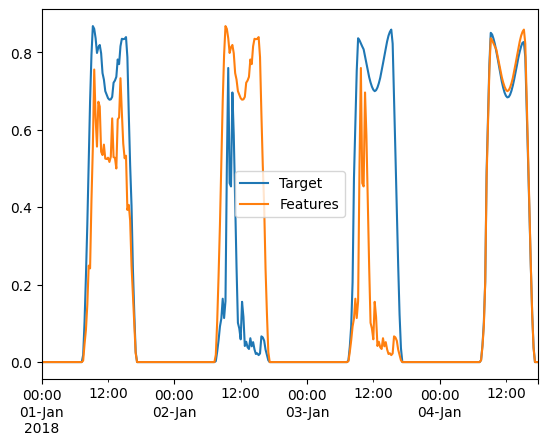

In [1022]:
target.iloc[:360].plot(label='Target')
features['actual power'].iloc[:360].plot(label='Features')
plt.legend()

In [1023]:
power_features = power_data.columns
weather_features = weather_data.columns

In [1024]:
# last 4 days will be reserved for testing
split_datetime = -day*4
x_train = features.iloc[:split_datetime]
x_test = features.iloc[split_datetime:]
y_train = target[:split_datetime]
y_test = target[split_datetime:]

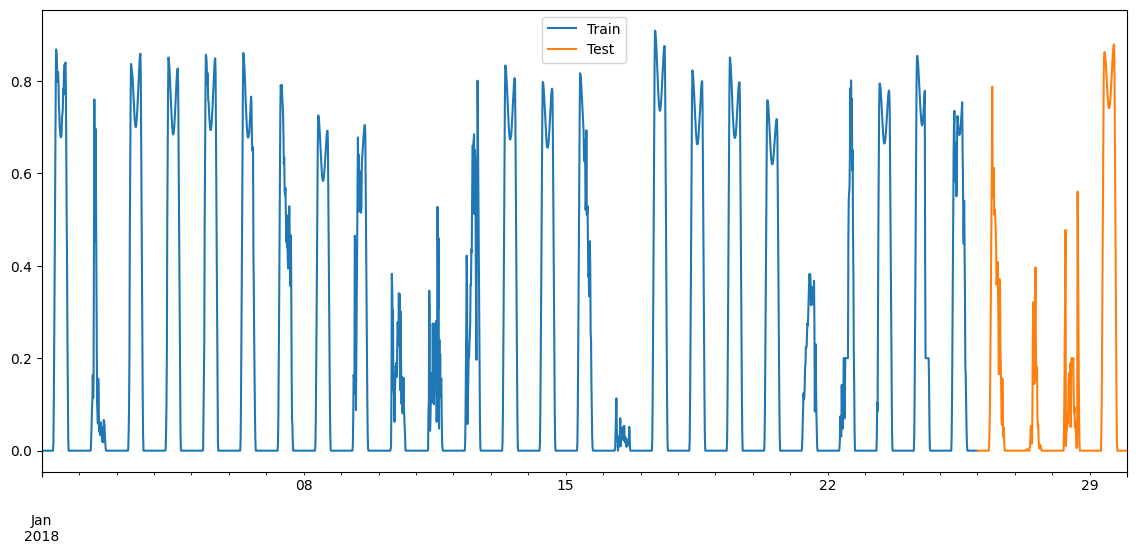

In [1025]:
# Plot AC power training and testing date splits
_ = pd.DataFrame(y_train) \
    .rename(columns={'actual power': 'Train'}) \
    .join(pd.DataFrame(y_test).rename(columns={'actual power': 'Test'}), how='outer') \
    .plot(figsize=(14,6))

In [1026]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute the accuracy errors : MAE, RMSE, R2 score.
def get_prediction_errors(y_true, y_pred):
    R2_score = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"R2 score: {R2_score}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    return [R2_score, mae, rmse]

In [1027]:
def plot_predictions(test, predicted):
    plt.figure(figsize=(14,6))
    plt.plot(test, label='Actual AC power', linewidth=3)
    plt.plot(predicted, label='Predicted AC power', linewidth=3)
    plt.xlabel('Time')
    plt.ylabel('AC Power Generated')
    plt.legend()
    plt.show()

In [1028]:
def plot_forecast_day(test, predicted, forecast_pred):
    date_range = pd.date_range(start="2018-01-30 23:45:00", periods=day, freq='15min')
    future_days = pd.DataFrame({'Date': date_range, 'Forecast': forecast_pred})
    future_days.index = future_days["Date"]
    plt.figure(figsize=(14,6))
    plt.plot(test, label='Actual AC power', linewidth=3)
    plt.plot(predicted, label='Predicted AC power', linewidth=3)
    plt.plot(future_days["Forecast"], label='Forecasted AC power', linewidth=3)
    plt.xlabel('Time')
    plt.ylabel('AC Power Generated')
    plt.legend()
    plt.show()

## Building ML Models

### 1- XGBoost :

In [1029]:
import xgboost as xgb

xgboost = xgb.XGBRegressor(n_estimators=200,
                           learning_rate=0.01,
                           max_depth=5,
                           min_child_weight=10,
                           base_score=0.5
                          )
xgboost.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=0)

,objective,'reg:squarederror'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


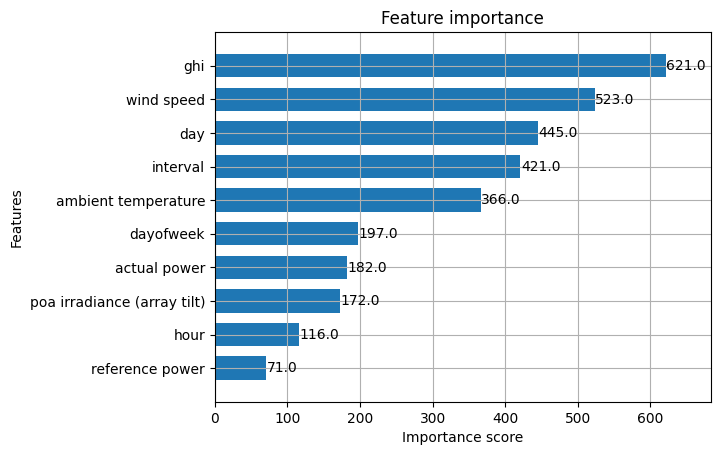

In [1037]:
_ = xgb.plot_importance(xgboost, height=0.7)

In [1031]:
predicted = xgboost.predict(x_test)
results = pd.concat([y_test, pd.Series(predicted, index=y_test.index)], axis=1)
results.index = data_all.index[-4*day:]
results.columns = ["Actual", "Predicted"]

In [1032]:
xgb_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.42258748288483583
MAE: 0.13919051401107826
RMSE: 0.18372729570423044


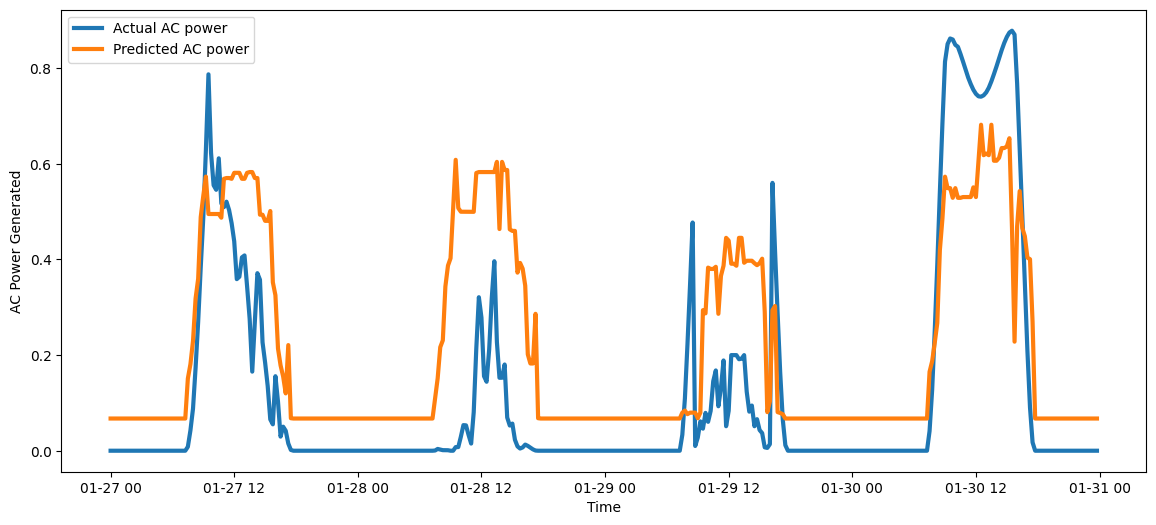

In [1033]:
plot_predictions(results["Actual"], results["Predicted"])

### Forecast Next Future Day

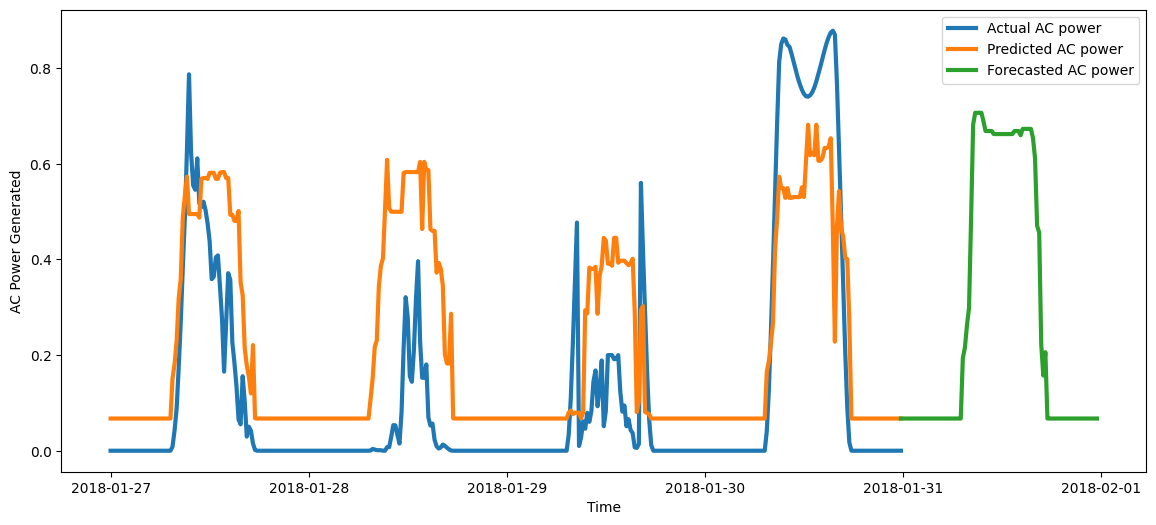

In [1034]:
last_day = data_all["2018-01-30 00:00:00":]
last_day_pred = xgboost.predict(last_day)
plot_forecast_day(results["Actual"], results["Predicted"], last_day_pred)